# Training hyperparameter optimization: PyTorch & Optuna

**Optuna Dashboard:** To monitor optimization progress in real-time, start the Optuna dashboard in a terminal:

```text
optuna-dashboard sqlite:///data/pytorch/training_optimization.db
```

Then open http://localhost:8080 in your browser.

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets

# Package imports
from image_classification_tools.pytorch import DataPipeline
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

Using device: cuda


### 1.2. Run configuration

In [2]:
# Model control
rerun_optuna_study = False   # Set to False to load existing Optuna study from disk
retrain_model = False        # Set to False to load existing final model
model_source = 'huggingface' # 'local' or 'huggingface'

# Optuna study configuration
study_name = 'training_optimization'
study_storage = 'sqlite:///../data/pytorch/cnn_optimization.db'

# Parallel GPU configuration
n_parallel_workers = torch.cuda.device_count() if torch.cuda.is_available() else 1

### 1.3. Fixed hyperparameters

In [3]:
# Data loading
preload_device = 'gpu' if torch.cuda.is_available() else 'cpu'

# Optuna optimization settings
n_trials = 100
epochs_per_trial = 50
pruner_warmup_steps = 5
trial_early_stopping_patience = 10

# Final model training settings
epochs = 500
early_stopping_patience = 15
print_every = 20

## 2. Load best architecture from architecture optimization

We'll load the best architecture hyperparameters from notebook 04.

In [4]:
# Load architecture optimization study from notebook 04
architecture_study = optuna.load_study(
    study_name='architecture_optimization',
    storage=study_storage
)

# Get best architecture parameters
arch_params = architecture_study.best_trial.params

print('Best architecture hyperparameters from notebook 04:\n')

for key, value in arch_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {architecture_study.best_value:.2f}%')

Best architecture hyperparameters from notebook 04:

  batch_size: 256
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 1
  conv_dropout_rate: 0.3970168590808983
  fc_dropout_rate: 0.41794948916615016
  pool_frequency: 4
  filter_double_frequency: 3
  learning_rate: 0.0003262697843356068

Best validation accuracy: 88.79%


## 3. Plot sample images

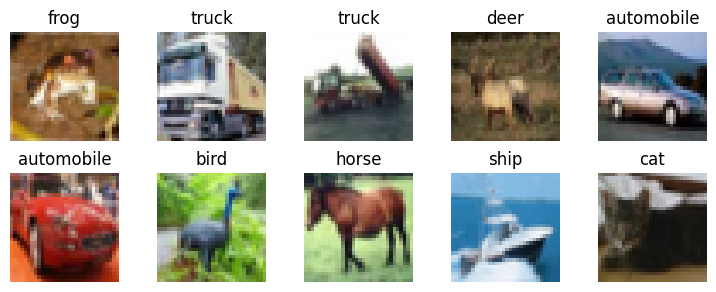

In [5]:
# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(
    root=config.DATA_DIR,
    train=True,
    transform=config.RGB_TRANSFORM
)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

## 4. Optuna training hyperparameter optimization

In [6]:
# Define model path
model_path = config.MODELS_DIR / 'training_optimized_cnn.pth'

# Load existing model if requested
if not retrain_model:

    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='training_optimized_cnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    # Try to load training history
    history = hf.load_history_from_source(
        model_path=model_path,
        model_name='training_optimized_cnn.pth',
        model_source=model_source
    )
    
    if model is None:
        print('Pretrained model not available, proceeding with training...')
        retrain_model = True

else:
    print('Training new model...')
    history = None

Model downloaded from Hugging Face


### 4.1. Define training hyperparameter search space

In [7]:
# Define training hyperparameter search space
search_space = {
    'batch_size': [64, 128, 256],
    'learning_rate': (1e-5, 1e-2, 'log'),
    'optimizer': ['Adam', 'AdamW', 'SGD'],
    'weight_decay': (1e-6, 1e-3, 'log')
}

print('Training hyperparameter search space:\n')

for key, value in search_space.items():
    print(f'  {key}: {value}')

Training hyperparameter search space:

  batch_size: [64, 128, 256]
  learning_rate: (1e-05, 0.01, 'log')
  optimizer: ['Adam', 'AdamW', 'SGD']
  weight_decay: (1e-06, 0.001, 'log')


### 4.2. Create CNN model factory (using best architecture)

In [8]:
def create_cnn(trial, num_classes, in_channels):
    '''Create a CNN with fixed architecture and trial-sampled training hyperparameters.
    
    Uses the best architecture from notebook 04, but samples training
    hyperparameters like optimizer, learning rate, etc.
    
    Args:
        trial: Optuna trial object for suggesting hyperparameters
        num_classes: Number of output classes
        in_channels: Number of input channels (3 for RGB, 1 for grayscale)
    
    Returns:
        nn.Sequential model
    '''
    
    # Use fixed architecture parameters from notebook 04
    n_conv_blocks = arch_params['n_conv_blocks']
    initial_filters = arch_params['initial_filters']
    n_fc_layers = arch_params['n_fc_layers']
    conv_dropout_rate = arch_params['conv_dropout_rate']
    fc_dropout_rate = arch_params['fc_dropout_rate']
    pool_frequency = arch_params.get('pool_frequency', 2)
    filter_double_frequency = arch_params.get('filter_double_frequency', 2)
    
    layers = []
    current_channels = in_channels
    spatial_size = 32  # CIFAR-10 input size
    
    # Convolutional blocks
    for block_idx in range(n_conv_blocks):

        # Double filters every N blocks
        out_channels = initial_filters * (2 ** (block_idx // filter_double_frequency))
        
        # First conv in block
        layers.append(nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        # Second conv in block
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        # Pool every N blocks
        should_pool = (block_idx + 1) % pool_frequency == 0

        if should_pool and spatial_size > 1:
            layers.append(nn.MaxPool2d(2, 2))
            spatial_size //= 2
        
        layers.append(nn.Dropout(conv_dropout_rate))
        current_channels = out_channels
    
    # Classifier with adaptive pooling
    layers.append(nn.AdaptiveAvgPool2d((1, 1)))
    layers.append(nn.Flatten())
    
    # Generate FC layer sizes
    fc_sizes = []
    current_fc_size = current_channels // 2

    for _ in range(n_fc_layers):
        fc_sizes.append(max(32, current_fc_size))
        current_fc_size //= 2
    
    # Add FC layers
    in_features = current_channels

    for fc_size in fc_sizes:
        layers.append(nn.Linear(in_features, fc_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(fc_dropout_rate))
        in_features = fc_size
    
    # Output layer
    layers.append(nn.Linear(in_features, num_classes))
    
    return nn.Sequential(*layers)

### 4.3. Run Optuna optimization study

In [9]:
%%time

if rerun_optuna_study:
    
    # Display parallel worker configuration
    print(f'Running optimization with {n_parallel_workers} parallel workers')

    if torch.cuda.is_available():
        print(f'Available GPUs: {torch.cuda.device_count()}')

        for i in range(torch.cuda.device_count()):
            print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
    
    # Create objective function
    objective = optimization.create_objective(
        model_factory=create_cnn,
        data_source=datasets.CIFAR10,
        data_dir=config.DATA_DIR,
        train_transform=config.RGB_TRANSFORM,
        eval_transform=config.RGB_TRANSFORM,
        n_epochs=epochs_per_trial,
        num_classes=len(config.CLASS_NAMES),
        in_channels=3,
        val_size=config.VAL_SIZE,
        search_space=search_space,
        early_stopping_patience=trial_early_stopping_patience
    )
    
    # Create Optuna study with pruning and database storage
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=study_storage,
        load_if_exists=True,
        pruner=optuna.pruners.MedianPruner(
            n_warmup_steps=pruner_warmup_steps
        )
    )
    
    # Run optimization
    study.optimize(
        objective, 
        n_trials=n_trials, 
        n_jobs=n_parallel_workers,
        catch=(optimization.TrialFailedError,)
    )
    
    print(f'\nBest trial: {study.best_trial.number}')
    print(f'Best validation accuracy: {study.best_value:.2f}%')

else:

    # Load existing study
    try:
        study = optuna.load_study(
            study_name=study_name,
            storage=study_storage
        )
        print(f'Study loaded from: {study_storage}')
        print(f'Study name: {study.study_name}')
        print(f'Number of trials: {len(study.trials)}')
        print(f'Best validation accuracy: {study.best_value:.2f}%')
        print(f'\nBest trial information:')
        print(f'  Trial number: {study.best_trial.number}')
        print(f'  Trial value: {study.best_trial.value:.2f}%')
        print(f'  Trial parameters:')
        for key, value in study.best_trial.params.items():
            print(f'    {key}: {value}')
    
    except KeyError:
        print(f'\nStudy "{study_name}" not found in database.')
        print('This study has not been run yet.')
        print('Please set rerun_optuna_study=True in the run configuration cell to create it.\n')
        raise

print()

Study loaded from: sqlite:///../data/pytorch/cnn_optimization.db
Study name: training_optimization
Number of trials: 139
Best validation accuracy: 91.57%

Best trial information:
  Trial number: 25
  Trial value: 91.57%
  Trial parameters:
    optimizer: SGD
    learning_rate: 0.010258532143373404
    weight_decay: 0.0021674627774374913
    label_smoothing: 0.003165204969827274
    lr_scheduler: step
    momentum: 0.9560066692269822
    nesterov: True

CPU times: user 525 ms, sys: 9.27 ms, total: 534 ms
Wall time: 533 ms


### 4.4. Visualize optimization results

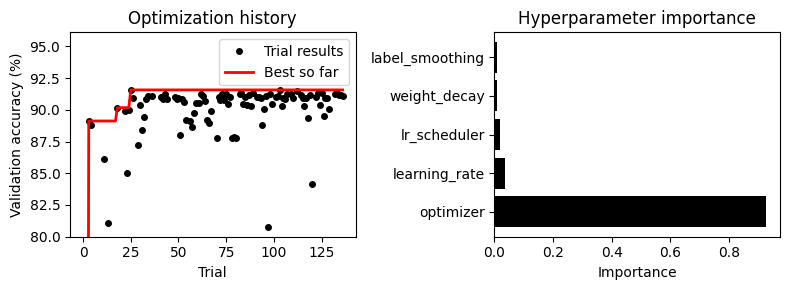

In [24]:
fig, axes = plots.plot_optimization_results(study, ylim=(80, None))
plt.show()

## 5. Train final model with best hyperparameters

### 5.1. Load winning hyperparameters

In [11]:
# Extract best hyperparameters
best_params = study.best_trial.params

print('Best hyperparameters:\n')

for key, value in best_params.items():
    print(f'  {key}: {value}')

Best hyperparameters:

  optimizer: SGD
  learning_rate: 0.010258532143373404
  weight_decay: 0.0021674627774374913
  label_smoothing: 0.003165204969827274
  lr_scheduler: step
  momentum: 0.9560066692269822
  nesterov: True


### 5.2. Re-create dataloader with winning batch size

In [12]:
# Recreate data loaders with best batch size from architecture optimization
best_batch_size = arch_params['batch_size']

loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split='train/val/test',
    train_transform=config.RGB_TRANSFORM,
    eval_transform=config.RGB_TRANSFORM,
    preload=preload_device,
    batch_size=best_batch_size,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    root=config.DATA_DIR
).get_loaders()

train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

Loading train dataset...
Loading test dataset...
Creating splits...
Preloading train to GPU:0...


Preloading train: 100%|██████████| 40000/40000 [00:15<00:00, 2544.75it/s]


Preloading val to GPU:0...


Preloading val: 100%|██████████| 10000/10000 [00:03<00:00, 2657.76it/s]


### 5.3. Create optimized model

In [13]:
if retrain_model:
    # Create model with best hyperparameters using the same factory function
    mock_trial = optimization.MockTrial(best_params)

    best_model = create_cnn(
        trial=mock_trial,
        num_classes=len(config.CLASS_NAMES),
        in_channels=3
    ).to(config.DEVICE)

    # Create optimizer with best hyperparameters
    optimizer_name = best_params['optimizer']
    learning_rate = best_params['learning_rate']
    weight_decay = best_params['weight_decay']
    
    if optimizer_name == 'Adam':
        best_optimizer = optim.Adam(
            best_model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name == 'AdamW':
        best_optimizer = optim.AdamW(
            best_model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name == 'SGD':
        best_optimizer = optim.SGD(
            best_model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
            momentum=0.9
        )
    
    # Set cross-entropy loss
    criterion = torch.nn.CrossEntropyLoss()

    # Get total trainable parameters
    trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

    print(f'\n{best_model}')
    print(f'\nTotal parameters: {trainable_params:,}')
else:
    # Use the loaded model
    best_model = model
    print('Using loaded model')
    print(f'\nTotal parameters: {sum(p.numel() for p in best_model.parameters()):,}')

Using loaded model

Total parameters: 1,920,970


### 5.4. Train optimized model

In [14]:
%%time

if retrain_model:
    history = training.train_model(
        model=best_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=best_optimizer,
        device=config.DEVICE,
        epochs=epochs,
        print_every=print_every,
        enable_early_stopping=True,
        early_stopping_patience=early_stopping_patience
    )

    print()
else:
    print('Training skipped - using loaded model\n')

Training skipped - using loaded model

CPU times: user 59 µs, sys: 6 µs, total: 65 µs
Wall time: 68.7 µs


### 5.5. Learning curves

In [15]:
if history is not None:
    fig, axes = plots.plot_learning_curves(history)
    plt.show()
else:
    print('No training history available')

No training history available


## 6. Evaluate optimized model on test set

### 6.1. Calculate test accuracy

In [16]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(
    best_model,
    test_loader
)

print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 89.96%


### 6.2. Per-class accuracy

In [17]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 89.80%
automobile  : 96.20%
bird        : 82.20%
cat         : 81.10%
deer        : 92.10%
dog         : 85.10%
frog        : 91.30%
horse       : 93.20%
ship        : 94.70%
truck       : 93.90%


### 6.3. Confusion matrix

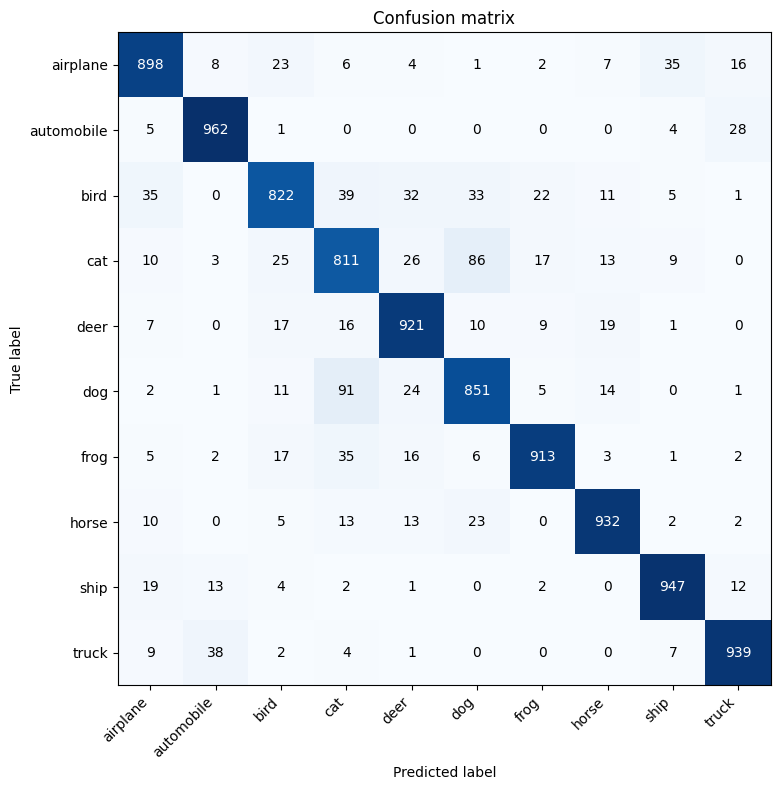

In [18]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 6.4. Predicted class probability distributions

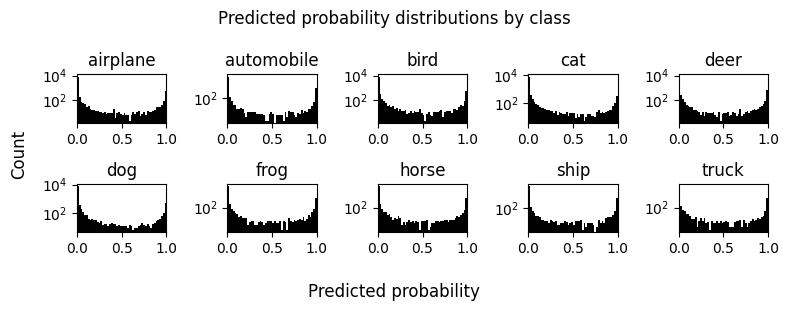

In [19]:
# Get predicted probabilities for all test samples
best_model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = best_model(images.to(config.DEVICE))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 6.5. Evaluation curves

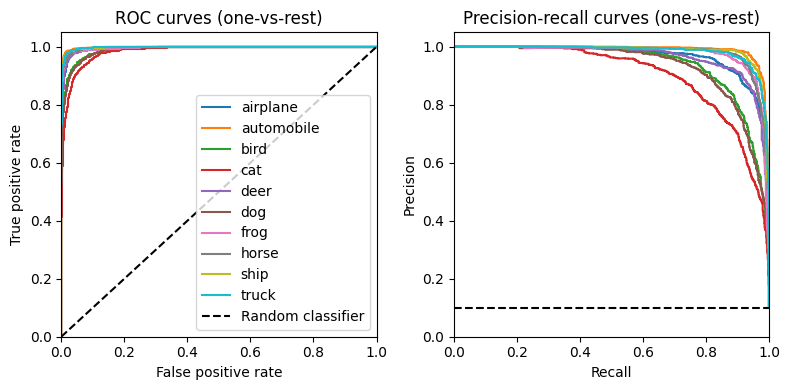

In [20]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 7. Save optimized model and hyperparameters

In [21]:
if retrain_model:

    # Save trained model (and auto-upload to Hugging Face if configured)
    # Extract database path from study_storage URI (same as notebook 04)
    study_db_path = config.DATA_DIR / 'pytorch' / 'cnn_optimization.db'
    
    hf.save_and_upload_model(
        model=best_model,
        model_path=model_path,
        model_name='training_optimized_cnn.pth',
        history=history,
        optuna_study_path=study_db_path,
        optuna_study_name='cnn_optimization.db'
    )

## 8. Save test results for comparison

In [22]:
# Save model performance results
results_path = config.RESULTS_DIR / 'training_optimized_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')

Test results saved to: ../data/pytorch/performance_results/training_optimized_cnn_results.pkl
  - Test accuracy: 89.96%
  - Total parameters: 1,920,970
  - Trainable parameters: 1,920,970
